In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

df = pd.read_csv("../data/product_metrics.csv")

# Create KPIs
df["Profit"] = df["Revenue"] - df["COGS"] - df["Marketing_Spend"]
df["ARPU"] = df["Revenue"] / df["Users"]
df["CAC"] = df["Marketing_Spend"] / df["Users"]

print(df.head())


   Quarter            Product   Users  Revenue  Marketing_Spend    COGS  \
0  2023-Q1      Cloud Storage  120000   850000           120000  300000   
1  2023-Q1  Streaming Service   95000   720000           110000  250000   
2  2023-Q1           AI Tools   40000   510000            90000  120000   
3  2023-Q2      Cloud Storage  135000   920000           130000  310000   
4  2023-Q2  Streaming Service  105000   780000           120000  260000   

   Profit       ARPU       CAC  
0  430000   7.083333  1.000000  
1  360000   7.578947  1.157895  
2  300000  12.750000  2.250000  
3  480000   6.814815  0.962963  
4  400000   7.428571  1.142857  


In [2]:
conn = sqlite3.connect(":memory:")

df.to_sql("product_metrics", conn, index=False, if_exists="replace")

query = """
SELECT Product,
       SUM(Revenue) AS Total_Revenue,
       SUM(Profit) AS Total_Profit
FROM product_metrics
GROUP BY Product
ORDER BY Total_Revenue DESC
"""

result = pd.read_sql_query(query, conn)

print(result)

             Product  Total_Revenue  Total_Profit
0      Cloud Storage        3850000       2030000
1  Streaming Service        3260000       1700000
2           AI Tools        2820000       1805000


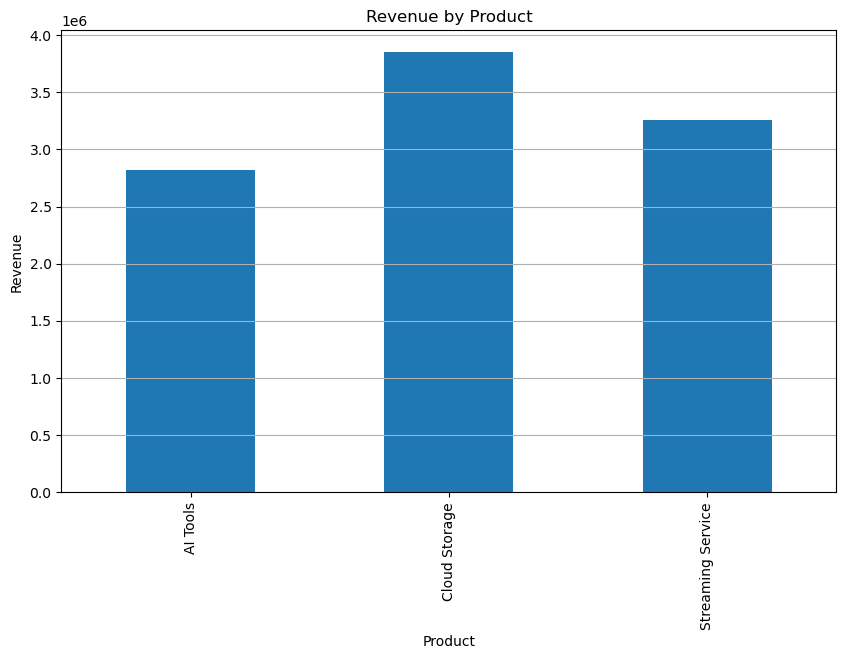

In [3]:
product_revenue = df.groupby("Product")["Revenue"].sum()

plt.figure(figsize=(10,6))

product_revenue.plot(kind="bar")

plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.xlabel("Product")

plt.grid(axis="y")

plt.savefig("product_revenue_chart.png", bbox_inches="tight")

plt.show()
